In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/air-passengers/AirPassengers.csv"

data = pd.read_csv(url)

values = data["#Passengers"].values.reshape(-1, 1)

scaler = MinMaxScaler()
values = scaler.fit_transform(values)

In [ ]:
X = []
y = []

time_steps = 12

for i in range(len(values) - time_steps):
    X.append(values[i:i + time_steps])
    y.append(values[i + time_steps])

X = np.array(X)
y = np.array(y)

In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, 1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1267
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0839
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0511
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0257
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0146
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0153
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0105
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0089
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0078
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0071 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0065 
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0059 
Epoch 16/20
7/7 ━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Actual Values:
[359. 310. 337. 360. 342. 406. 396. 420. 472. 548. 559. 463. 407. 362.
 405. 417. 391. 419. 461. 472. 535. 622. 606. 508. 461. 390. 432.]

Predicted Values:
[404.92715 407.02548 407.89072 408.46106 410.83377 413.81195 419.6411
 425.45847 430.5759  432.36887 435.29285 439.27182 445.10428 451.90906
 459.0694  467.5305  474.94788 481.6309  485.04935 492.76825 497.3739
 500.87332 504.38104 506.94247 513.3851  522.90405 528.999  ]


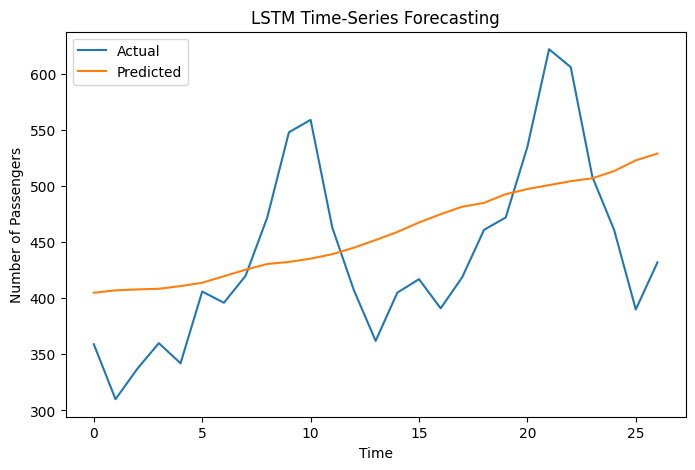

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

print("Actual Values:")
print(actual.flatten())

print("\nPredicted Values:")
print(predictions.flatten())

plt.figure(figsize=(8, 5))
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.title("LSTM Time-Series Forecasting")

plt.legend()
plt.show()